--- Starting Grouped Bar Chart: Scenarios by Category vs LSTM vs SARIMA ---
Total scenarios to analyze: 18
Groups: ['Baseline (No income)', 'Uniform pop. + Income', 'Randomized pop. + Income', 'Environmentalist + Income', 'Wasteful + Income', 'Uniform pop. + Random Income']
Scenarios loaded: 18 scenarios, 120 months
LSTM data loaded: 120 months


c:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\ProgramData\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Success! Grouped bar chart saved at: ..\figuras\figure-barplot-grupos-cenarios-vs-lstm-sarima.pdf

SUMMARY BY GROUP (Annual Average Consumption 2026-2035)

Baseline (No income):
  Mean (10-year): 2248.5k m³
  Min: 2211.8k m³
  Max: 2279.2k m³

Uniform pop. + Income:
  Mean (10-year): 2288.8k m³
  Min: 2212.4k m³
  Max: 2356.4k m³

Randomized pop. + Income:
  Mean (10-year): nank m³
  Min: nank m³
  Max: nank m³

Environmentalist + Income:
  Mean (10-year): 2237.9k m³
  Min: 2209.7k m³
  Max: 2261.4k m³

Wasteful + Income:
  Mean (10-year): nank m³
  Min: nank m³
  Max: nank m³

Uniform pop. + Random Income:
  Mean (10-year): nank m³
  Min: nank m³
  Max: nank m³

SARIMA Statistical Model:
  Mean (10-year): 2264.1k m³
  Min: 2264.1k m³
  Max: 2264.1k m³

LSTM Neural Network:
  Mean (10-year): 2160.1k m³
  Min: 2158.3k m³
  Max: 2160.9k m³

--- Analysis Complete ---


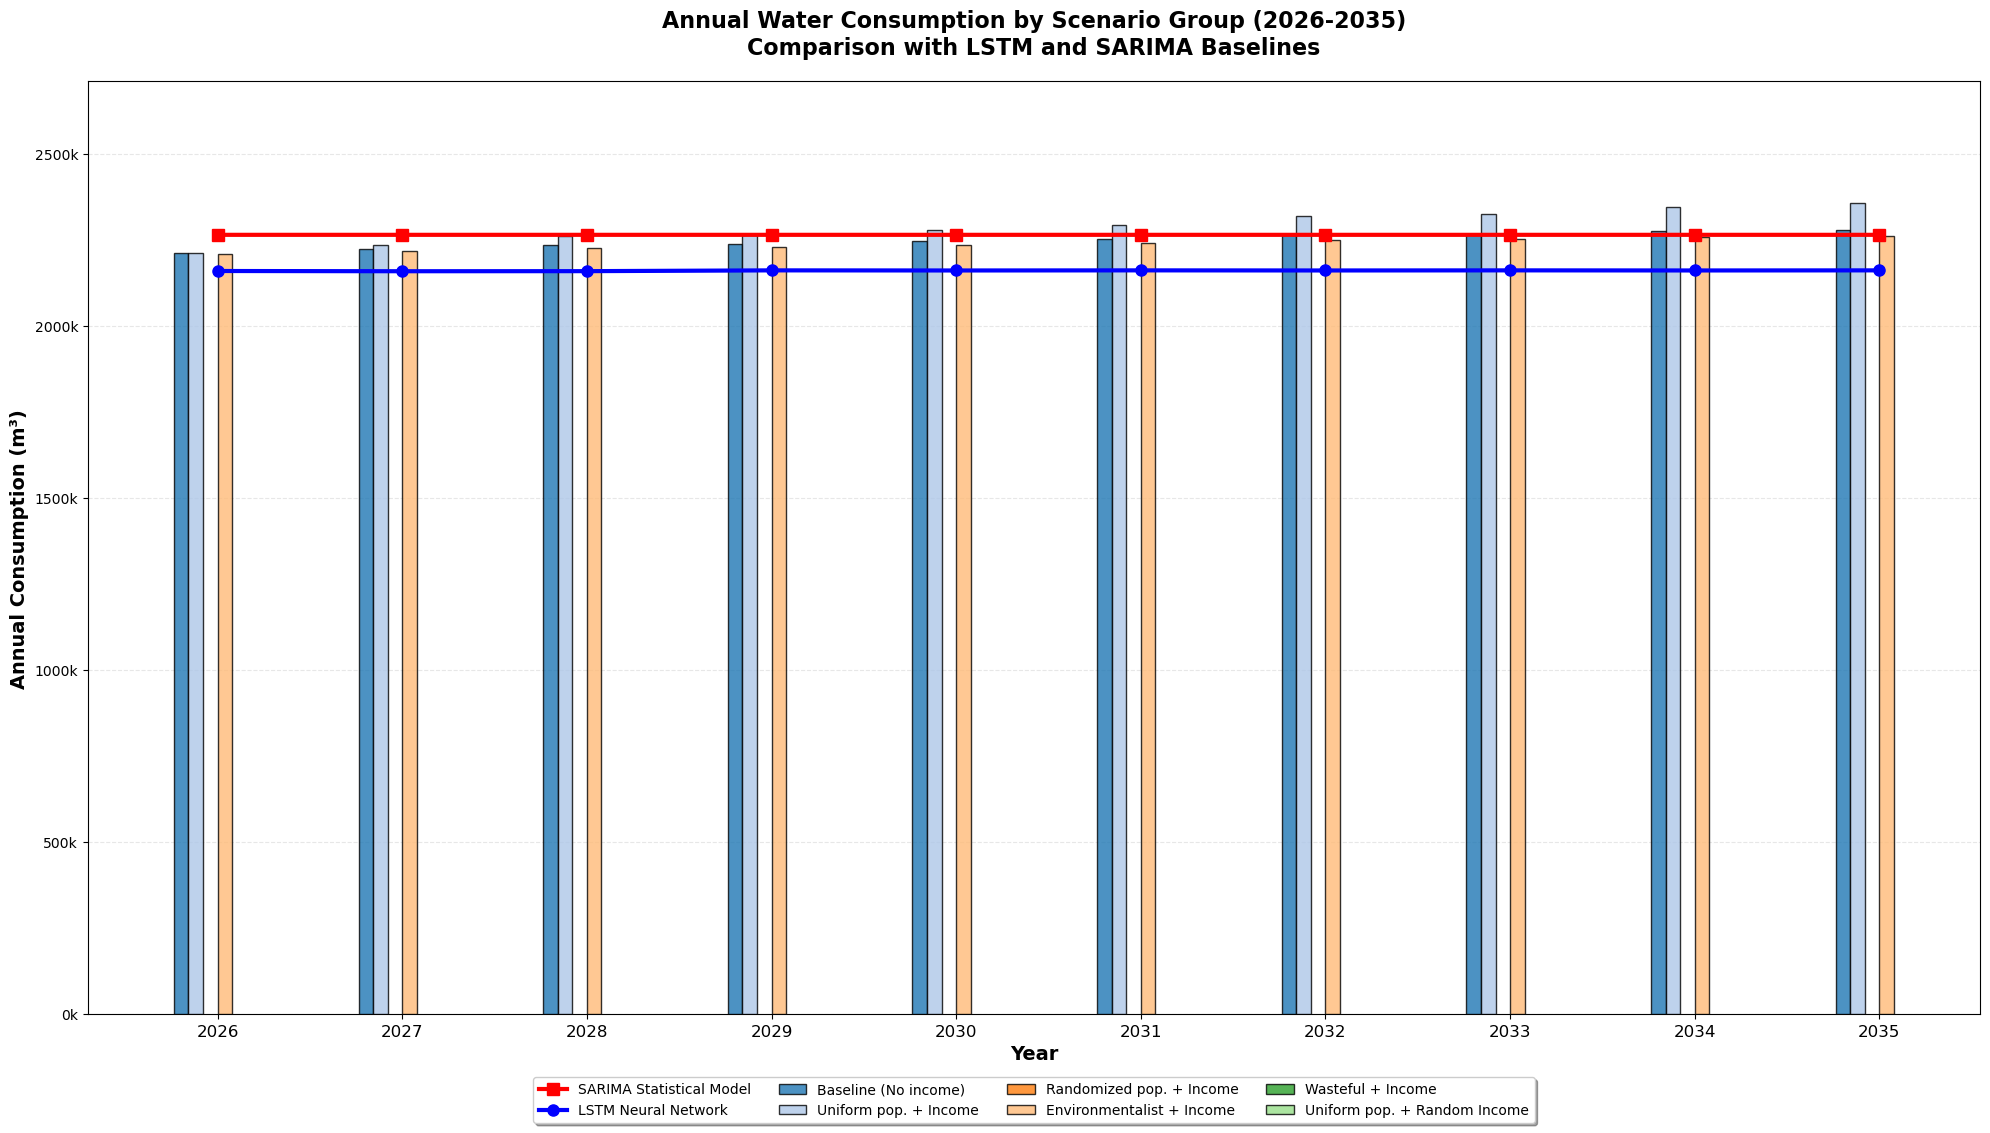

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configuration and Paths
# ==========================================
BASE_PATH = '..'

np.random.seed(42)

SCENARIO_FILE = 'consumo_previsto_todos_cenarios.csv'
LSTM_FILE = 'previsoes_futuras_2026_2035.csv'
SARIMA_FILE = 'previsao_consumo_sarima_2026_2035.csv'

OUTPUT_FILENAME = 'figure-barplot-grupos-cenarios-vs-lstm-sarima.pdf'

FIGURE_WIDTH = 20
FIGURE_HEIGHT = 12

INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

def sum_yearly(df, date_col, value_cols):
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Starting Grouped Bar Chart: Scenarios by Category vs LSTM vs SARIMA ---")

    # ==========================================
    # 2. Define Scenario Groups
    # ==========================================
    
    # Group definitions based on the table
    scenario_groups = {
        'Baseline (No income)': ['CI', 'CII', 'CIII'],
        'Uniform pop. + Income': ['CIV', 'CV', 'CVI'],
        'Randomized pop. + Income': ['CVII', 'CVIII', 'CIX'],
        'Environmentalist + Income': ['CX', 'CXI', 'CXII'],
        'Wasteful + Income': ['CXIII', 'CXIV', 'CXV'],
        'Uniform pop. + Random Income': ['CXXI', 'CXXII', 'CXXIII']
    }
    
    # Flatten list of all scenarios for data loading
    all_scenarios = []
    for scenarios in scenario_groups.values():
        all_scenarios.extend(scenarios)
    
    print(f"Total scenarios to analyze: {len(all_scenarios)}")
    print(f"Groups: {list(scenario_groups.keys())}")

    # ==========================================
    # 3. Data Loading
    # ==========================================
    
    # Load Scenarios
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    if not os.path.exists(path_scenarios):
        print(f"Error: Scenarios file not found: {path_scenarios}")
        return

    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')
    
    # Get full column names that match our scenarios
    scenario_cols_full = []
    scenario_mapping = {}  # Maps full name to short name
    for col in df_scenarios.columns:
        for scenario in all_scenarios:
            if col.startswith(scenario) or col == scenario:
                if col not in ['Mes', 'Ano', 'Mes_Ano', 'Date']:
                    scenario_cols_full.append(col)
                    scenario_mapping[col] = scenario
                    break
    
    # Filter to desired period
    df_scenarios = df_scenarios[(df_scenarios['Date'] >= '2026-01-01') & (df_scenarios['Date'] <= '2035-12-31')]
    print(f"Scenarios loaded: {len(scenario_cols_full)} scenarios, {len(df_scenarios)} months")

    # Load SARIMA
    path_sarima = os.path.join(INPUT_DIR_MODELS, SARIMA_FILE)
    if not os.path.exists(path_sarima):
        print(f"Error: SARIMA file not found: {path_sarima}")
        return
        
    df_sarima = pd.read_csv(path_sarima)
    df_sarima = df_sarima.rename(columns={'Date': 'Date', 'Projected_Consumption': 'SARIMA'})
    df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
    df_sarima = df_sarima[(df_sarima['Date'] >= '2026-01-01') & (df_sarima['Date'] <= '2035-12-31')]

    # Load LSTM
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    df_lstm = None
    if os.path.exists(path_lstm):
        df_lstm = pd.read_csv(path_lstm, sep=",")
        if 'Data' in df_lstm.columns:
            df_lstm['Date'] = pd.to_datetime(df_lstm['Data'])
        elif 'date' in df_lstm.columns:
            df_lstm['Date'] = pd.to_datetime(df_lstm['date'])
        
        if 'Valor Previsto' in df_lstm.columns:
            df_lstm.rename(columns={'Valor Previsto': 'LSTM'}, inplace=True)
        elif 'predicted' in df_lstm.columns:
            df_lstm.rename(columns={'predicted': 'LSTM'}, inplace=True)
        
        df_lstm = df_lstm[(df_lstm['Date'] >= '2026-01-01') & (df_lstm['Date'] <= '2035-12-31')]
        print(f"LSTM data loaded: {len(df_lstm)} months")
    else:
        print(f"Warning: LSTM file not found at {path_lstm}")

    # ==========================================
    # 4. Calculate Annual Averages by Group
    # ==========================================
    
    # Merge all data
    df_combined = df_scenarios.copy()
    df_combined = pd.merge(df_combined, df_sarima[['Date', 'SARIMA']], on='Date', how='left')
    
    # Calculate annual totals
    all_cols = scenario_cols_full + ['SARIMA']
    df_annual = sum_yearly(df_combined, 'Date', all_cols)
    
    # Rename columns to short names
    df_annual = df_annual.rename(columns=scenario_mapping)
    
    # Calculate LSTM annual totals
    df_lstm_annual = None
    if df_lstm is not None:
        df_lstm_annual = sum_yearly(df_lstm, 'Date', ['LSTM'])
    
    # Calculate annual averages for each group
    years = df_annual['Year'].values
    group_annual_averages = {}
    
    for group_name, scenarios in scenario_groups.items():
        group_yearly_avg = []
        for year in years:
            year_values = []
            for scenario in scenarios:
                if scenario in df_annual.columns:
                    year_values.append(df_annual[df_annual['Year'] == year][scenario].values[0])
            group_yearly_avg.append(np.mean(year_values))
        group_annual_averages[group_name] = group_yearly_avg
    
    # Get SARIMA annual values
    sarima_annual = df_annual['SARIMA'].values
    
    # Get LSTM annual values if available
    lstm_annual = None
    if df_lstm_annual is not None:
        lstm_annual = df_lstm_annual['LSTM'].values
    
    # ==========================================
    # 5. Create Grouped Bar Chart
    # ==========================================
    
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    
    # Bar settings
    n_groups = len(scenario_groups)
    n_years = len(years)
    bar_width = 0.12  # Width for each group bar
    group_spacing = 0.8  # Spacing between year groups
    
    # Colors for each group (using tab20)
    tab20_colors = [plt.cm.tab20(i) for i in range(20)]
    group_colors = {group: tab20_colors[i % 20] for i, group in enumerate(scenario_groups.keys())}
    
    # Calculate positions for bars
    year_positions = np.arange(n_years) * (n_groups * bar_width + group_spacing)
    
    # Plot bars for each group
    for i, (group_name, yearly_avgs) in enumerate(group_annual_averages.items()):
        bar_positions = year_positions + i * bar_width
        bars = ax.bar(bar_positions, yearly_avgs, bar_width, 
                     label=group_name, color=group_colors[group_name],
                     alpha=0.8, edgecolor='black', linewidth=1, zorder=5)
        
        # Add value labels on top of each bar (optional - can be removed if too crowded)
        # for j, (pos, val) in enumerate(zip(bar_positions, yearly_avgs)):
        #     ax.text(pos, val + 5000, f'{val/1000:.0f}k', 
        #             ha='center', va='bottom', fontsize=6, rotation=90)
    
    # Plot SARIMA line
    sarima_positions = year_positions + (n_groups - 1) * bar_width / 2
    ax.plot(sarima_positions, sarima_annual, color='red', linestyle='-', 
            linewidth=3, marker='s', markersize=8, label='SARIMA Statistical Model', zorder=10)
    
    # Plot LSTM line if available
    if lstm_annual is not None:
        ax.plot(sarima_positions, lstm_annual, color='blue', linestyle='-', 
                linewidth=3, marker='o', markersize=8, label='LSTM Neural Network', zorder=10)
    
    # ==========================================
    # 6. Formatting
    # ==========================================
    
    # Set x-axis ticks at the center of each year group
    tick_positions = year_positions + (n_groups - 1) * bar_width / 2
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(years.astype(int), fontsize=12)
    
    ax.set_ylabel('Annual Consumption (m³)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=14, fontweight='bold')
    
    # Format y-axis with 'k' suffix
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, p: f'{y/1000:.0f}k'))
    
    # Adjust y-axis limits to give more space
    y_max_all = max([max(v) for v in group_annual_averages.values()] + [max(sarima_annual)])
    if lstm_annual is not None:
        y_max_all = max(y_max_all, max(lstm_annual))
    ax.set_ylim(0, y_max_all * 1.15)  # Add 15% margin at the top
    
    # Add grid
    ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)
    
    # Add title
    plt.title('Annual Water Consumption by Scenario Group (2026-2035)\nComparison with LSTM and SARIMA Baselines', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Legend at the bottom (below x-axis)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.06), 
              fontsize=10, frameon=True, shadow=True, ncol=4)
    
    # Adjust layout to make room for legend at bottom
    plt.subplots_adjust(bottom=0.15)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Extra space for legend
    
    # Save
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    full_output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
    plt.savefig(full_output_path, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"\nSuccess! Grouped bar chart saved at: {full_output_path}")
    
    # ==========================================
    # 7. Print Summary Statistics
    # ==========================================
    print("\n" + "="*70)
    print("SUMMARY BY GROUP (Annual Average Consumption 2026-2035)")
    print("="*70)
    
    for group_name, yearly_avgs in group_annual_averages.items():
        print(f"\n{group_name}:")
        print(f"  Mean (10-year): {np.mean(yearly_avgs)/1000:.1f}k m³")
        print(f"  Min: {np.min(yearly_avgs)/1000:.1f}k m³")
        print(f"  Max: {np.max(yearly_avgs)/1000:.1f}k m³")
    
    print(f"\nSARIMA Statistical Model:")
    print(f"  Mean (10-year): {np.mean(sarima_annual)/1000:.1f}k m³")
    print(f"  Min: {np.min(sarima_annual)/1000:.1f}k m³")
    print(f"  Max: {np.max(sarima_annual)/1000:.1f}k m³")
    
    if lstm_annual is not None:
        print(f"\nLSTM Neural Network:")
        print(f"  Mean (10-year): {np.mean(lstm_annual)/1000:.1f}k m³")
        print(f"  Min: {np.min(lstm_annual)/1000:.1f}k m³")
        print(f"  Max: {np.max(lstm_annual)/1000:.1f}k m³")
    
    print("\n--- Analysis Complete ---")
    plt.show()

if __name__ == "__main__":
    main()